# 📊 Aprendizaje No Supervisado (Unsupervised Learning)

El **aprendizaje no supervisado** es un tipo de aprendizaje automático donde los modelos se entrenan con datos **sin etiquetas** (sin variable objetivo).

👉 El objetivo es descubrir **patrones, estructuras ocultas o relaciones** dentro de los datos.

---

## 🧠 Características principales

- No existe variable dependiente (target)
- Se trabaja con datos no etiquetados
- Busca patrones, agrupaciones o representaciones
- Es exploratorio

---

## 🎯 Objetivos comunes

- Agrupar datos similares (clustering)
- Reducir dimensiones (simplificar datos)
- Detectar anomalías
- Extraer características relevantes

---

## 🔑 Tipos principales de modelos

---

### 1. 📌 Clustering (Agrupamiento)

Agrupa datos en función de su similitud.

#### 🔹 Algoritmos comunes:

- **K-Means**
- **DBSCAN**
- **Hierarchical Clustering (Clustering Jerárquico)**

---

### 2. 📉 Reducción de Dimensionalidad

Reduce el número de variables manteniendo la mayor información posible.

#### 🔹 Algoritmos comunes:

- **PCA (Principal Component Analysis)**
- **t-SNE**



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# IMPORTAMOS LIBREARIAS PARA KMEANS

In [2]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import SilhouetteVisualizer

# GENERAMOS DATOS ALEATORIOS PARA EL EJEMPLO con MAKE_BLOBS

In [3]:
X,y,c = make_blobs(500,cluster_std=0.8,centers=4,n_features=2,return_centers=True)

# CREO DATAFRAME CON CENTROIDES

In [4]:
df_blobs = pd.DataFrame(
    {
        'x1':X[:,0],
        'x2':X[:,1],
        'y':y
    }
)
df_blobs

,x1,x2,y
0,1.497428,-7.068294,1
1,6.256155,7.332555,2
2,-4.571982,-2.279258,3
3,4.733752,-9.055593,0
4,5.662706,-9.054025,0
...,...,...,...
495,7.921110,7.563795,2
496,7.146975,6.387850,2
497,1.100546,-8.148826,1
498,5.809511,-10.380533,0


In [5]:
df_centers = pd.DataFrame(
    {
        'x1':c[:,0],
        'x2':c[:,1]
    }
)
df_centers

,x1,x2
0,5.745106,-9.293344
1,0.526251,-7.353538
2,6.430762,6.662869
3,-5.308145,-4.438094


# GRAFICAMOS LOS DATOS

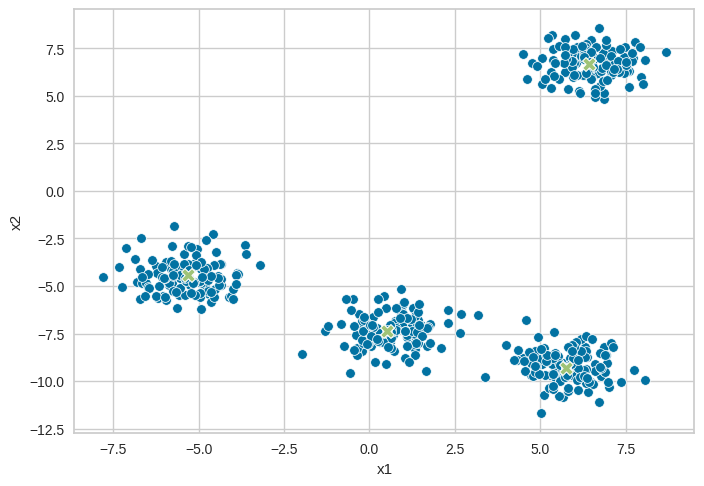

In [6]:
sns.scatterplot(data=df_blobs,x='x1',y='x2')
sns.scatterplot(data=df_centers,x='x1',y='x2',marker='X',s=100)
plt.show()

# APLICAMOS K-MEANS

In [7]:
kmeans = KMeans(n_clusters=4)
df_cluster = kmeans.fit_predict(X)
df_blobs['cluster'] = df_cluster
df_blobs

,x1,x2,y,cluster
0,1.497428,-7.068294,1,3
1,6.256155,7.332555,2,1
2,-4.571982,-2.279258,3,0
3,4.733752,-9.055593,0,2
4,5.662706,-9.054025,0,2
...,...,...,...,...
495,7.921110,7.563795,2,1
496,7.146975,6.387850,2,1
497,1.100546,-8.148826,1,3
498,5.809511,-10.380533,0,2


In [8]:
k_means_centers = kmeans.cluster_centers_
df_k_means_center = pd.DataFrame(
    {
        'x1':k_means_centers[:,0],
        'x2':k_means_centers[:,1]
    }
)
df_k_means_center

,x1,x2
0,-5.351937,-4.490892
1,6.436701,6.690553
2,5.771569,-9.210728
3,0.658104,-7.323311


# GRAFICAMOS LOS RESULTADOS DE K-MEANS

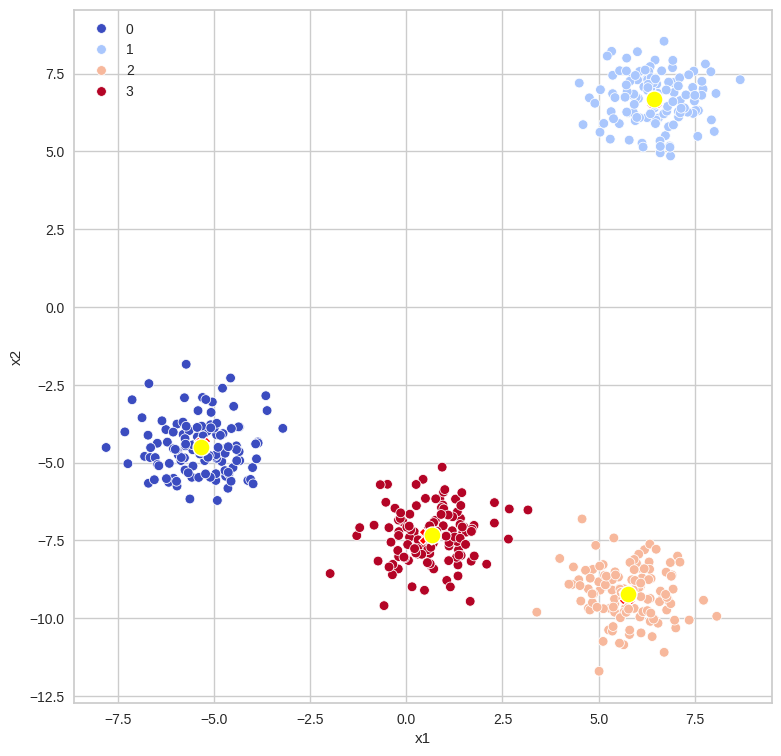

In [9]:
fig = plt.figure(figsize=(9,9))
sns.scatterplot(data=df_blobs,x='x1',y='x2',hue='cluster',palette='coolwarm')
sns.scatterplot(data=df_centers,  x='x1', y='x2', marker='X', s=150 , color='red')
sns.scatterplot(data=df_k_means_center,  x='x1', y='x2', marker='o', s=150 , color='yellow')
plt.show()